In [31]:
import pandas as pd

df = pd.read_csv("/content/all_rooms_timetable.csv")
keep_cols = [
    "room_name",
    "room_id",
    "day",
    "time_slot",
    "subject",
    "facultyName",
    "batch",
    "program"
]

df = df[keep_cols]

# Remove duplicates
df = df.drop_duplicates()

df.to_csv("clean_timetable.csv", index=False)

print("Saved clean_timetable.csv")
print(df.head())

Saved clean_timetable.csv
     room_name  room_id     day time_slot  \
0  1101_BL1_FF        1  Monday     09:00   
1  1101_BL1_FF        1  Monday     10:00   
2  1101_BL1_FF        1  Monday     11:00   
3  1101_BL1_FF        1  Monday     11:00   
4  1101_BL1_FF        1  Monday     13:00   

                                subject           facultyName  \
0  Linear Algebra and Numerical Methods        Narra Lavanya    
1                       Data Structures          M Sheshikala   
2                Appled Physics for CSE           Dr. B. Babu   
3                Appled Physics for CSE  Dr. G. Thirumala Rao   
4            Probability and Statistics    Dr. T. Kiran Kumar   

                       batch program  
0               25CAIBTCSB45   BTECH  
1  24BTCAICSB15,24BTCAICSB16   BTECH  
2               25CAIBTDSB57   BTECH  
3               25CAIBTDSB58   BTECH  
4               25CAIBTAIB21   BTECH  


In [3]:
def find_free_rooms(day, time_slot):
    all_rooms = set(df["room_name"].astype(str))

    occupied = set(
        df[(df["day"] == day) & (df["time_slot"] == time_slot)]["room_name"].astype(str)
    )

    free = sorted(all_rooms - occupied)
    return free

# Example usage:
day = "Monday"
time_slot = "10:00"

free_rooms = find_free_rooms(day, time_slot)
print(f"Free rooms on {day} at {time_slot}:")
print(free_rooms)

Free rooms on Monday at 10:00:
['0000', '0001', '1009', '1011', '1013_A', '1013_B', '1104_B_BL1_FF', '1105_B_BL1_FF', '1106_B_BL1_FF', '1114_B_BL1_FF', '1201_A_BL1_SF', '1201_B_BL1_SF', '1203_BL1_SF', '1210_B_BL1_SF', '2004-BL-2-GF', '2005_BL2_GF', '2011-BL-2-GF', '2013-BL-2-GF', '2015-BL-2-GF', '2015_B_BL2_GF', '2108_BL2_FF', '2204', '2212-BL-2-SF', '2214_A_BL2_SF ', '3003_B_BL3_GF', '3007_B_BL3_GF', '3013_A', '3013_B', '3018_BL3_GF ', '3101_B_BL3_FF', '3112A_BL3_FF', '3204_BL3_SF', '3205_BL3_SF', '3206_BL3_SF', '3208_BL3_SF', '3209_BL3_SF', '3216_BL3_SF', '3217_BL3_SF', '3218_BL3_SF', '4610_BL4_GF', '4712_BL4_GF', '4814_BL4_GF', '5007_A_BL5_GF', '5015_BL5_GF', '5017_BL5_GF', '5019_BL5_GF', '5022_BL5_GF', '6201-BL6-SF', '6202-BL6-SF', '6205-BL6-SF', '7003_A_BL7_GF', '7003_B_BL7_GF', '7004_Srix_GF', '7005_Srix_GF', '7105_Srix_FF', '7201-SRiX-SF', '7202-SRiX-SF', '7205-SRiX-SF', '8006_BL8_GF', '8202', '8204', '8205', 'Field instructional classroom-1', 'Field instructional classroom-3', 

In [4]:
def room_timetable(room_name):
    room_df = df[df["room_name"] == room_name].sort_values(["day", "time_slot"])
    return room_df

print(room_timetable("1101_BL1_FF"))

      room_name  room_id        day time_slot  \
45  1101_BL1_FF        1     Friday     09:00   
46  1101_BL1_FF        1     Friday     09:00   
47  1101_BL1_FF        1     Friday     10:00   
48  1101_BL1_FF        1     Friday     10:00   
49  1101_BL1_FF        1     Friday     11:00   
50  1101_BL1_FF        1     Friday     11:00   
51  1101_BL1_FF        1     Friday     12:00   
52  1101_BL1_FF        1     Friday     13:00   
53  1101_BL1_FF        1     Friday     14:00   
54  1101_BL1_FF        1     Friday     15:00   
55  1101_BL1_FF        1     Friday     16:00   
0   1101_BL1_FF        1     Monday     09:00   
1   1101_BL1_FF        1     Monday     10:00   
2   1101_BL1_FF        1     Monday     11:00   
3   1101_BL1_FF        1     Monday     11:00   
4   1101_BL1_FF        1     Monday     13:00   
5   1101_BL1_FF        1     Monday     14:00   
6   1101_BL1_FF        1     Monday     14:00   
7   1101_BL1_FF        1     Monday     15:00   
8   1101_BL1_FF     

In [5]:
usage = df.groupby("room_name").size().sort_values(ascending=False)

print("Most used rooms:")
print(usage.head(10))

print("\nLeast used rooms:")
print(usage.tail(10))

Most used rooms:
room_name
2104-BL-2-FF     83
9101_BL9_FF      67
3203_BL3_SF      65
0000             64
2213_A_BL2_SF    63
1102_BL1_FF      60
2218_BL2_SF      58
1101_BL1_FF      56
2103_BL2_FF      55
2202_BL2_SF      55
dtype: int64

Least used rooms:
room_name
1013_B           2
3013_B           2
7003_B_BL7_GF    2
8205             2
4712_BL4_GF      2
7003_A_BL7_GF    2
8202             2
8204             2
2005_BL2_GF      1
1104_B_BL1_FF    1
dtype: int64


In [6]:
peak = df.groupby(["day", "time_slot"]).size().sort_values(ascending=False)
print("Peak time slots:")
print(peak.head(10))

Peak time slots:
day        time_slot
Tuesday    16:00        192
           15:00        180
Wednesday  16:00        178
           15:00        178
Thursday   16:00        176
Friday     10:00        174
Wednesday  10:00        174
           09:00        172
Monday     15:00        170
Tuesday    10:00        169
dtype: int64


In [7]:
conflicts_room = (
    df.groupby(["room_name", "day", "time_slot"])
      .size()
      .reset_index(name="count")
)

conflicts_room = conflicts_room[conflicts_room["count"] > 1]
print("Room conflicts:")
print(conflicts_room)

Room conflicts:
        room_name        day time_slot  count
11           0000     Sunday     09:00     10
12           0000     Sunday     10:00      8
13           0000     Sunday     11:00      6
14           0000     Sunday     12:00      6
15           0000     Sunday     14:00      6
...           ...        ...       ...    ...
5453  9106_BL9_FF     Friday     14:00      2
5455  9106_BL9_FF     Monday     11:00      2
5457  9106_BL9_FF     Monday     13:00      2
5465  9106_BL9_FF   Thursday     09:00      2
5481  9106_BL9_FF  Wednesday     14:00      2

[557 rows x 4 columns]


In [8]:
conflicts_faculty = (
    df.groupby(["facultyName", "day", "time_slot"])
      .size()
      .reset_index(name="count")
)

conflicts_faculty = conflicts_faculty[conflicts_faculty["count"] > 1]
print("Faculty conflicts:")
print(conflicts_faculty)

Faculty conflicts:
           facultyName        day time_slot  count
34      AMBATI SUVARNA   Thursday     12:00      3
37      AMBATI SUVARNA  Wednesday     12:00      3
60    APARNA NANDIGAMA   Thursday     12:00      2
61    APARNA NANDIGAMA  Wednesday     12:00      2
212       B Giri Rajan     Friday     15:00      2
...                ...        ...       ...    ...
5620       Sudharani V    Tuesday     16:00      2
5753    TALLA SHIRISHA     Friday     13:00      2
5758    TALLA SHIRISHA    Tuesday     09:00      2
5759    TALLA SHIRISHA  Wednesday     09:00      2
6000    Vydehi Pingili   Thursday     16:00      2

[174 rows x 4 columns]


In [9]:
# Count how many slots each room is used
usage = df.groupby("room_name").size().reset_index(name="used_slots")

# Find total possible slots
days = df["day"].nunique()
slots_per_day = df["time_slot"].nunique()
total_slots = days * slots_per_day

usage["utilization_percent"] = (usage["used_slots"] / total_slots) * 100

# Sort
usage_sorted = usage.sort_values("utilization_percent", ascending=False)

print("Most used rooms:")
print(usage_sorted.head(10))

print("\nLeast used rooms (underused):")
print(usage_sorted.tail(10))

# Save report
usage_sorted.to_csv("room_utilization_report.csv", index=False)
print("Saved room_utilization_report.csv")

Most used rooms:
         room_name  used_slots  utilization_percent
55    2104-BL-2-FF          83            98.809524
201    9101_BL9_FF          67            79.761905
121    3203_BL3_SF          65            77.380952
0             0000          64            76.190476
78   2213_A_BL2_SF          63            75.000000
7      1102_BL1_FF          60            71.428571
83     2218_BL2_SF          58            69.047619
6      1101_BL1_FF          56            66.666667
54     2103_BL2_FF          55            65.476190
69     2202_BL2_SF          55            65.476190

Least used rooms (underused):
         room_name  used_slots  utilization_percent
5           1013_B           2             2.380952
94          3013_B           2             2.380952
165  7003_B_BL7_GF           2             2.380952
195           8205           2             2.380952
142    4712_BL4_GF           2             2.380952
164  7003_A_BL7_GF           2             2.380952
193           82

In [10]:
peak = (
    df.groupby(["day", "time_slot"])
      .size()
      .reset_index(name="classes_running")
      .sort_values("classes_running", ascending=False)
)

print("Top 10 peak slots:")
print(peak.head(10))

print("\nLeast busy slots:")
print(peak.tail(10))

peak.to_csv("peak_hours_report.csv", index=False)
print("Saved peak_hours_report.csv")

Top 10 peak slots:
          day time_slot  classes_running
65    Tuesday     16:00              192
64    Tuesday     15:00              180
77  Wednesday     16:00              178
76  Wednesday     15:00              178
53   Thursday     16:00              176
1      Friday     10:00              174
71  Wednesday     10:00              174
70  Wednesday     09:00              172
18     Monday     15:00              170
59    Tuesday     10:00              169

Least busy slots:
          day time_slot  classes_running
33   Saturday     18:00                2
21     Monday     18:00                2
79  Wednesday     18:00                2
45     Sunday     18:00                2
34   Saturday     19:00                2
40     Sunday     13:00                2
67    Tuesday     18:00                2
35   Saturday     20:00                1
66    Tuesday     17:00                1
78  Wednesday     17:00                1
Saved peak_hours_report.csv


In [12]:
threshold = 30  # % utilization threshold (you can justify this in report)

underused = usage_sorted[usage_sorted["utilization_percent"] < threshold]

print("Underused rooms (<30% utilization):")
print(underused)

underused.to_csv("underused_rooms.csv", index=False)
print("Saved underused_rooms.csv")

Underused rooms (<30% utilization):
         room_name  used_slots  utilization_percent
150    5019_BL5_GF          25            29.761905
120    3202_BL3_SF          25            29.761905
47     2014_BL2_GF          25            29.761905
64     2115_BL2_FF          24            28.571429
171   7204_Srix_SF          24            28.571429
..             ...         ...                  ...
164  7003_A_BL7_GF           2             2.380952
193           8202           2             2.380952
194           8204           2             2.380952
40     2005_BL2_GF           1             1.190476
10   1104_B_BL1_FF           1             1.190476

[69 rows x 3 columns]
Saved underused_rooms.csv


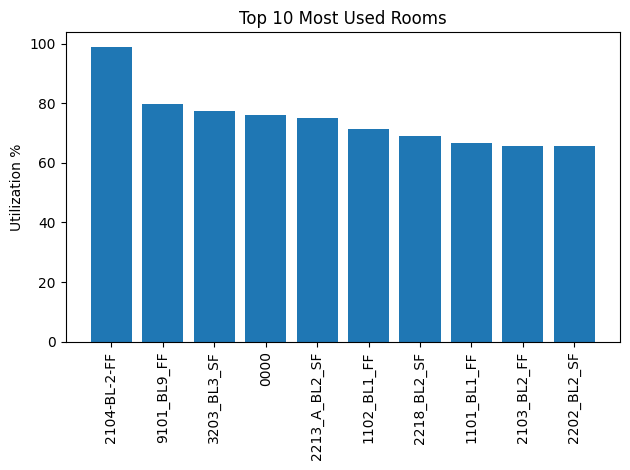

In [13]:
import matplotlib.pyplot as plt

top10 = usage_sorted.head(10)

plt.figure()
plt.bar(top10["room_name"], top10["utilization_percent"])
plt.xticks(rotation=90)
plt.title("Top 10 Most Used Rooms")
plt.ylabel("Utilization %")
plt.tight_layout()
plt.show()

In [14]:
print("Days:", df["day"].nunique())
print("Slots per day:", df["time_slot"].nunique())
print("Total possible slots per room:", total_slots)

Days: 7
Slots per day: 12
Total possible slots per room: 84


In [15]:
total_rooms = usage_sorted.shape[0]

avg_util = usage_sorted["utilization_percent"].mean()

under_30 = (usage_sorted["utilization_percent"] < 30).sum()
over_70 = (usage_sorted["utilization_percent"] > 70).sum()

print("Total rooms:", total_rooms)
print("Average utilization %:", round(avg_util, 2))
print("Rooms under 30%:", under_30, f"({under_30/total_rooms*100:.1f}%)")
print("Rooms over 70%:", over_70, f"({over_70/total_rooms*100:.1f}%)")

Total rooms: 213
Average utilization %: 35.45
Rooms under 30%: 69 (32.4%)
Rooms over 70%: 6 (2.8%)


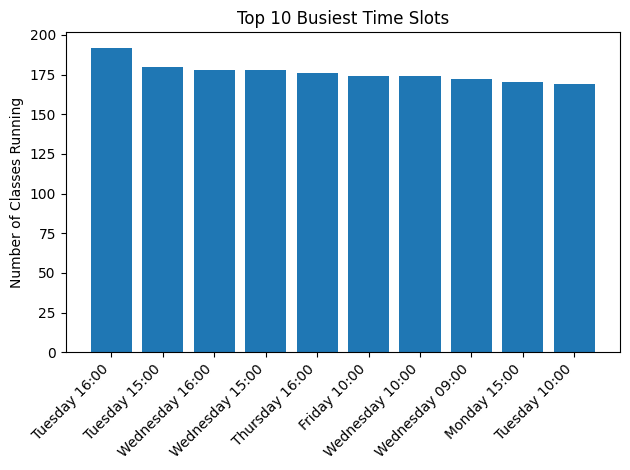

In [16]:
peak = (
    df.groupby(["day", "time_slot"])
      .size()
      .reset_index(name="classes_running")
      .sort_values("classes_running", ascending=False)
)

top10_peak = peak.head(10)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    top10_peak["day"] + " " + top10_peak["time_slot"],
    top10_peak["classes_running"]
)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Busiest Time Slots")
plt.ylabel("Number of Classes Running")
plt.tight_layout()
plt.show()

#project 2nd version


In [17]:
import pandas as pd

df = pd.read_csv("/content/all_rooms_timetable.csv")

# Make sure room_name is string
df["room_name"] = df["room_name"].astype(str)

# Extract block like BL1, BL2, ...
df["block"] = df["room_name"].str.extract(r"(BL\d+)")

print(df[["room_name", "block"]].head())

     room_name block
0  1101_BL1_FF   BL1
1  1101_BL1_FF   BL1
2  1101_BL1_FF   BL1
3  1101_BL1_FF   BL1
4  1101_BL1_FF   BL1


In [18]:
# Room Usage Count (Core Metric)

# Each row = one class happening in that room.

room_usage = df.groupby(["block", "room_name"]).size().reset_index(name="usage_count")

In [19]:
most_used = room_usage.loc[room_usage.groupby("block")["usage_count"].idxmax()]
print("Most used rooms per block:")
print(most_used)

Most used rooms per block:
    block      room_name  usage_count
1     BL1    1102_BL1_FF           61
64    BL2  2213_A_BL2_SF           63
105   BL3    3203_BL3_SF           65
123   BL4    4101_BL4_GF           26
135   BL5    5020_BL5_GF           28
141   BL6    6103-BL6-FF           24
148   BL7  7003_A_BL7_GF            2
159   BL8    8008_BL8_GF           47
175   BL9    9101_BL9_FF           67


In [20]:
least_used = room_usage.loc[room_usage.groupby("block")["usage_count"].idxmin()]
print("Least used rooms per block:")
print(least_used)

Least used rooms per block:
    block      room_name  usage_count
4     BL1  1104_B_BL1_FF            1
33    BL2    2005_BL2_GF            1
95    BL3   3112A_BL3_FF            6
126   BL4    4712_BL4_GF            2
128   BL5  5007_A_BL5_GF            6
146   BL6    6205-BL6-SF            4
148   BL7  7003_A_BL7_GF            2
157   BL8    8005_BL8_GF           27
176   BL9    9102_BL9_FF           36


In [21]:
time_usage = df.groupby("time").size().reset_index(name="usage_count")

peak_time = time_usage.loc[time_usage["usage_count"].idxmax()]
dead_time = time_usage.loc[time_usage["usage_count"].idxmin()]

print("Peak time:", peak_time)
print("Least used time:", dead_time)

Peak time: time           10:00
usage_count      909
Name: 1, dtype: object
Least used time: time           18:00
usage_count       17
Name: 9, dtype: object


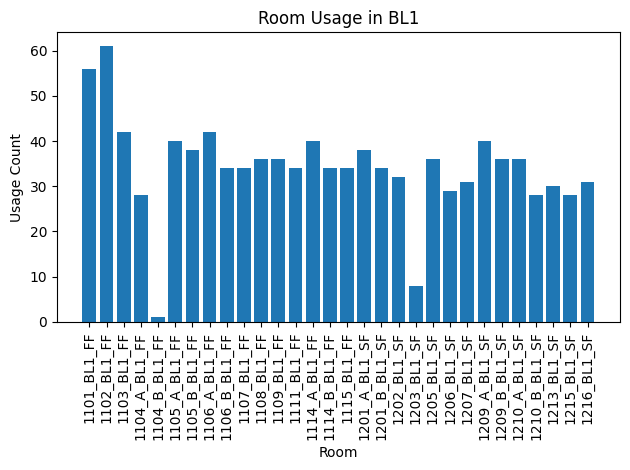

In [22]:
import matplotlib.pyplot as plt

block = "BL1"  # change this or connect to UI later

block_data = room_usage[room_usage["block"] == block]

plt.figure()
plt.bar(block_data["room_name"], block_data["usage_count"])
plt.xticks(rotation=90)
plt.title(f"Room Usage in {block}")
plt.xlabel("Room")
plt.ylabel("Usage Count")
plt.tight_layout()
plt.show()

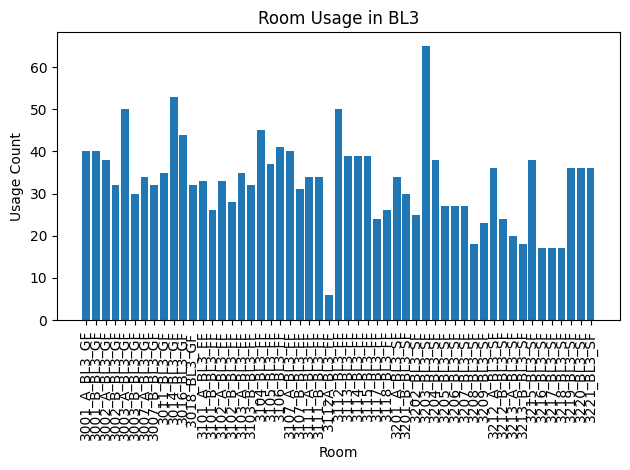

In [23]:
import matplotlib.pyplot as plt

block = "BL3"  # change this or connect to UI later

block_data = room_usage[room_usage["block"] == block]

plt.figure()
plt.bar(block_data["room_name"], block_data["usage_count"])
plt.xticks(rotation=90)
plt.title(f"Room Usage in {block}")
plt.xlabel("Room")
plt.ylabel("Usage Count")
plt.tight_layout()
plt.show()

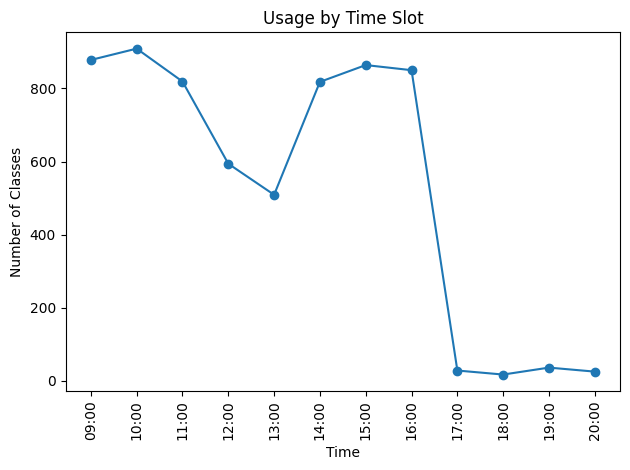

In [24]:
plt.figure()
plt.plot(time_usage["time"], time_usage["usage_count"], marker="o")
plt.xticks(rotation=90)
plt.title("Usage by Time Slot")
plt.xlabel("Time")
plt.ylabel("Number of Classes")
plt.tight_layout()
plt.show()

In [25]:
!zip -r my_project.zip .

  adding: .config/ (stored 0%)
  adding: .config/.last_update_check.json (deflated 22%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.01.16/ (stored 0%)
  adding: .config/logs/2026.01.16/14.24.13.071214.log (deflated 87%)
  adding: .config/logs/2026.01.16/14.23.31.981136.log (deflated 92%)
  adding: .config/logs/2026.01.16/14.24.18.954466.log (deflated 58%)
  adding: .config/logs/2026.01.16/14.24.28.646070.log (deflated 57%)
  adding: .config/logs/2026.01.16/14.24.29.392089.log (deflated 56%)
  adding: .config/logs/2026.01.16/14.24.03.314209.log (deflated 58%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/active_config (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/hi

In [27]:
!zip -r my_project.zip project1/

	zip warning: name not matched: project1/

zip error: Nothing to do! (try: zip -r my_project.zip . -i project1/)
